# TP 2 — Eigenfaces : solution commentée

Solution complète du [TP 2](./enonce.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

faces = fetch_olivetti_faces(shuffle=True, random_state=0)
images, y = faces.images, faces.target
h, w = images.shape[1:]
X = images.reshape(len(images), -1)

## Exercice 1 — PCA

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)

pca = PCA(n_components=150, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print(f"variance expliquée (150 comp.) : {pca.explained_variance_ratio_.sum():.3f}")

variance expliquée (150 comp.) : 0.973


## Exercice 2 — Eigenfaces

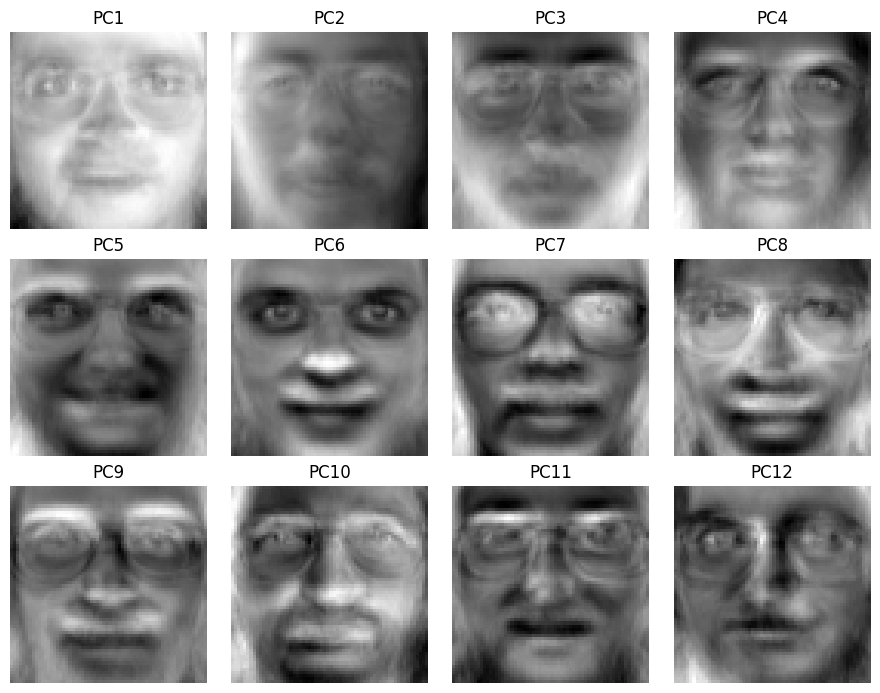

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(h, w), cmap="gray")
    ax.set_title(f"PC{i + 1}")
    ax.axis("off")
plt.tight_layout()

## Exercice 3 — Reconnaissance par SVM

In [4]:
clf = SVC(kernel="rbf", C=1e3, gamma=0.005, class_weight="balanced")
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)

print(f"accuracy test : {clf.score(X_test_pca, y_test):.3f}")
print(classification_report(y_test, y_pred, zero_division=0))

accuracy test : 0.960
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         2
           3       0.75      1.00      0.86         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      0.67      0.80         3
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         3
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       0.00      0.00      0.00         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
     

Text(0.5, 1.0, 'Matrice de confusion 40×40')

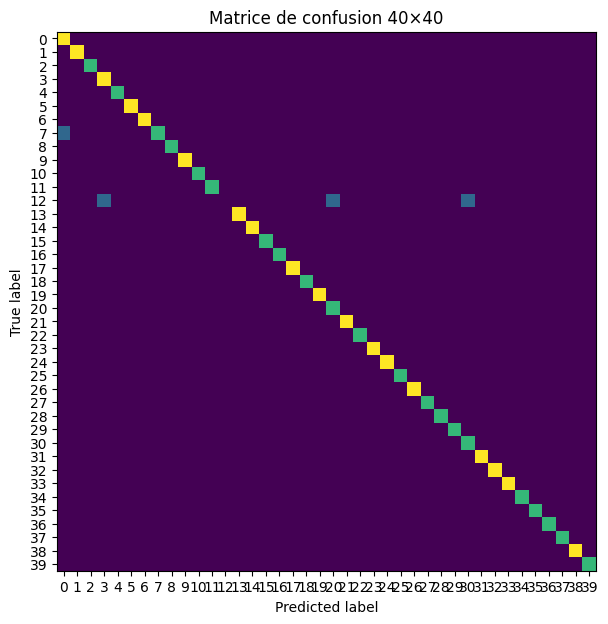

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False, include_values=False)
ax.set_title("Matrice de confusion 40×40")

## Exercice 4 — Courbe accuracy vs n_components

In [8]:
X_train.shape

(300, 4096)

n= 10  acc=0.900
n= 25  acc=0.940
n= 50  acc=0.960
n=100  acc=0.950
n=150  acc=0.960
n=200  acc=0.940
n=280  acc=0.900


Text(0.5, 1.0, 'Eigenfaces : accuracy vs nombre de composantes')

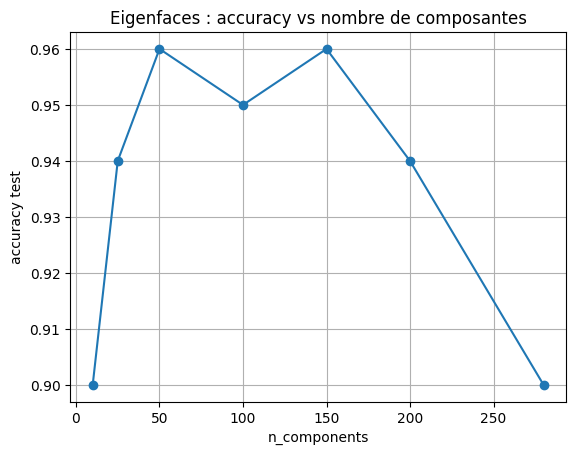

In [9]:
ns = [10, 25, 50, 100, 150, 200, 280]
accs = []
for n in ns:
    p = PCA(n_components=n, whiten=True, random_state=0).fit(X_train)
    Xtr_p = p.transform(X_train)
    Xte_p = p.transform(X_test)
    c = SVC(kernel="rbf", C=1e3, gamma=0.005, class_weight="balanced").fit(Xtr_p, y_train)
    accs.append(c.score(Xte_p, y_test))
    print(f"n={n:3d}  acc={accs[-1]:.3f}")

plt.plot(ns, accs, "o-")
plt.xlabel("n_components")
plt.ylabel("accuracy test")
plt.grid(True)
plt.title("Eigenfaces : accuracy vs nombre de composantes")

**Discussion** : l'accuracy croît rapidement puis plafonne — typiquement autour de 50-100 composantes pour Olivetti. Au-delà, on capture surtout du bruit. C'est un argument fort pour utiliser PCA + classifieur classique sur visage : peu de dimensions, peu de données nécessaires, et un modèle interprétable (on peut visualiser ce qu'apprend le système).